In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Configuraciones básicas
sns.set()
plt.rcParams['figure.figsize'] = (10, 6)

print("ANALISIS ECOBICI")
print("Enfoque: Estaciones y comportamiento de usuarios")
print("Iniciando carga de datos...")


In [ ]:
# Cargar datos directamente desde CSV
print("Cargando dataset desde archivo CSV...")

try:
    bici_df = pd.read_csv('2025-04.csv')
    print(f"Dataset cargado: {len(bici_df):,} registros")
    
    # Info básica del dataset
    print(f"\nInformación del dataset:")
    print(f"   Filas: {bici_df.shape[0]:,}")
    print(f"   Columnas: {bici_df.shape[1]}")
    
    print("\nPrimeras 3 filas del dataset:")
    print(bici_df.head(3))
    
except Exception as e:
    print(f"Error en la carga: {str(e)}")
    bici_df = pd.DataFrame()


In [ ]:
# Procesamiento de datos
if not bici_df.empty:
    # Calcular duración de viajes
    bici_df['timestamp_inicio'] = pd.to_datetime(bici_df['Fecha_Retiro'] + ' ' + bici_df['Hora_Retiro'])
    bici_df['timestamp_fin'] = pd.to_datetime(bici_df['Fecha_Arribo'] + ' ' + bici_df['Hora_Arribo'])
    bici_df['duracion_mins'] = (bici_df['timestamp_fin'] - bici_df['timestamp_inicio']).dt.total_seconds() / 60
    
    # Limpiar datos extremos
    bici_clean = bici_df[
        (bici_df['duracion_mins'] > 0) & 
        (bici_df['duracion_mins'] < 120) &
        (bici_df['Edad_Usuario'] > 10) & 
        (bici_df['Edad_Usuario'] < 80)
    ].copy()
    
    print(f"Datos limpiados: {len(bici_clean):,} viajes válidos")
    
    # Análisis de estaciones más populares
    estaciones_origen = bici_clean['Ciclo_Estacion_Retiro'].value_counts().head(10)
    estaciones_destino = bici_clean['Ciclo_EstacionArribo'].value_counts().head(10)
    
    print(f"\nANALISIS DE ESTACIONES:")
    print(f"Estación más popular (origen): {estaciones_origen.index[0]} - {estaciones_origen.iloc[0]:,} viajes")
    print(f"Total de estaciones únicas (origen): {bici_clean['Ciclo_Estacion_Retiro'].nunique()}")
    
    # Análisis demográfico básico
    print(f"\nANALISIS DEMOGRAFICO:")
    genero_counts = bici_clean['Genero_Usuario'].value_counts()
    for genero, count in genero_counts.items():
        pct = count / len(bici_clean) * 100
        print(f"   {genero}: {count:,} viajes ({pct:.1f}%)")
    
    # Crear categorías de duración
    def categorizar_duracion(mins):
        if mins <= 15:
            return 'Corto'
        elif mins <= 30:
            return 'Medio'  
        else:
            return 'Largo'
    
    bici_clean['categoria_duracion'] = bici_clean['duracion_mins'].apply(categorizar_duracion)
    categoria_counts = bici_clean['categoria_duracion'].value_counts()
    
    print(f"\nDISTRIBUCION POR DURACION:")
    for cat, count in categoria_counts.items():
        pct = count / len(bici_clean) * 100
        print(f"   {cat}: {count:,} viajes ({pct:.1f}%)")
        
else:
    print("No se pudieron procesar los datos")


In [ ]:
# Visualizaciones básicas con Seaborn
if not bici_df.empty:
    # Crear visualizaciones
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. Top 10 estaciones de origen
    top_origen_df = estaciones_origen.head(10).reset_index()
    top_origen_df.columns = ['estacion', 'viajes']
    sns.barplot(data=top_origen_df, x='viajes', y='estacion', ax=axes[0,0])
    axes[0,0].set_title('Top 10 Estaciones de Origen')
    axes[0,0].set_xlabel('Número de Viajes')
    
    # 2. Distribución por género
    sns.countplot(data=bici_clean, x='Genero_Usuario', ax=axes[0,1])
    axes[0,1].set_title('Distribución por Género')
    axes[0,1].set_xlabel('Género')
    axes[0,1].set_ylabel('Número de Viajes')
    
    # 3. Distribución de categorías de duración
    sns.countplot(data=bici_clean, x='categoria_duracion', ax=axes[1,0])
    axes[1,0].set_title('Distribución por Duración')
    axes[1,0].set_xlabel('Categoría de Duración')
    axes[1,0].set_ylabel('Número de Viajes')
    
    # 4. Duración por género
    sns.boxplot(data=bici_clean, x='Genero_Usuario', y='duracion_mins', ax=axes[1,1])
    axes[1,1].set_title('Duración por Género')
    axes[1,1].set_xlabel('Género')
    axes[1,1].set_ylabel('Duración (minutos)')
    axes[1,1].set_ylim(0, 80)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas adicionales
    print(f"\nMETRICAS ADICIONALES:")
    
    # Viajes circulares (mismo origen y destino)
    viajes_circulares = len(bici_clean[bici_clean['Ciclo_Estacion_Retiro'] == bici_clean['Ciclo_EstacionArribo']])
    pct_circulares = viajes_circulares / len(bici_clean) * 100
    print(f"Viajes circulares: {viajes_circulares:,} ({pct_circulares:.2f}%)")
    
    # Duración promedio por género
    duracion_genero = bici_clean.groupby('Genero_Usuario')['duracion_mins'].mean()
    print(f"\nDuración promedio por género:")
    for genero, duracion in duracion_genero.items():
        print(f"   {genero}: {duracion:.1f} minutos")
        
else:
    print("No se pueden generar visualizaciones")


In [ ]:
# Modelo simple de regresión lineal
if not bici_df.empty and len(bici_clean) > 1000:
    print("MODELO DE REGRESION LINEAL")
    print("Preparando datos para modelo...")
    
    # Preparar variables simples para el modelo
    modelo_df = bici_clean[['Edad_Usuario', 'duracion_mins']].copy()
    modelo_df = modelo_df.dropna()
    
    # Variables independientes y dependiente
    X = modelo_df[['Edad_Usuario']]
    y = modelo_df['duracion_mins']
    
    # Crear y entrenar modelo
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Hacer predicciones
    y_pred = modelo.predict(X)
    
    # Métricas
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = modelo.score(X, y)
    
    print(f"\nRESULTADOS DEL MODELO:")
    print(f"   RMSE: {rmse:.2f} minutos")
    print(f"   R²: {r2:.4f}")
    print(f"   Coeficiente (Edad): {modelo.coef_[0]:.4f}")
    print(f"   Intercepto: {modelo.intercept_:.2f}")
    
    # Visualización del modelo
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gráfico 1: Predicciones vs Reales
    sample_size = min(1000, len(y))
    sample_idx = np.random.choice(len(y), sample_size, replace=False)
    sns.scatterplot(x=y.iloc[sample_idx], y=y_pred[sample_idx], 
                    alpha=0.5, ax=axes[0])
    axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    axes[0].set_xlabel('Duración Real (min)')
    axes[0].set_ylabel('Duración Predicha (min)')
    axes[0].set_title(f'Modelo (R²: {r2:.3f})')
    
    # Gráfico 2: Edad vs Duración
    sns.scatterplot(data=modelo_df.sample(1000), x='Edad_Usuario', y='duracion_mins', 
                    alpha=0.5, ax=axes[1])
    axes[1].plot(modelo_df['Edad_Usuario'], y_pred, color='red', linewidth=2)
    axes[1].set_xlabel('Edad del Usuario')
    axes[1].set_ylabel('Duración (min)')
    axes[1].set_title('Regresión: Edad vs Duración')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No hay suficientes datos para el modelo")


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Configuraciones básicas
sns.set()
plt.rcParams['figure.figsize'] = (10, 6)

print("ANALISIS ECOBICI")
print("Enfoque: Estaciones y comportamiento de usuarios")
print("Iniciando carga de datos...")


ANALISIS ECOBICI
Enfoque: Estaciones y comportamiento de usuarios
Iniciando carga de datos...


In [ ]:
# Cargar datos directamente desde CSV
print("Cargando dataset desde archivo CSV...")

try:
    bici_df = pd.read_csv('2025-04.csv')
    print(f"Dataset cargado: {len(bici_df):,} registros")
    
    # Info básica del dataset
    print(f"\nInformación del dataset:")
    print(f"   Filas: {bici_df.shape[0]:,}")
    print(f"   Columnas: {bici_df.shape[1]}")
    
    print("\nPrimeras 3 filas del dataset:")
    print(bici_df.head(3))
    
except Exception as e:
    print(f"Error en la carga: {str(e)}")
    bici_df = pd.DataFrame()


Cargando dataset...
Dataset cargado: 500,000 registros

Información del dataset:
   Filas: 500,000
   Columnas: 9


In [3]:
# Procesamiento de datos
if not bici_df.empty:
    # Calcular duración de viajes
    bici_df['timestamp_inicio'] = pd.to_datetime(bici_df['Fecha_Retiro'] + ' ' + bici_df['Hora_Retiro'])
    bici_df['timestamp_fin'] = pd.to_datetime(bici_df['Fecha_Arribo'] + ' ' + bici_df['Hora_Arribo'])
    bici_df['duracion_mins'] = (bici_df['timestamp_fin'] - bici_df['timestamp_inicio']).dt.total_seconds() / 60
    
    # Limpiar datos extremos
    bici_clean = bici_df[
        (bici_df['duracion_mins'] > 0) & 
        (bici_df['duracion_mins'] < 120) &
        (bici_df['Edad_Usuario'] > 10) & 
        (bici_df['Edad_Usuario'] < 80)
    ].copy()
    
    print(f"Datos limpiados: {len(bici_clean):,} viajes válidos")
    
    # Análisis de estaciones más populares
    estaciones_origen = bici_clean['Ciclo_Estacion_Retiro'].value_counts().head(10)
    estaciones_destino = bici_clean['Ciclo_EstacionArribo'].value_counts().head(10)
    
    print(f"\nANALISIS DE ESTACIONES:")
    print(f"Estación más popular (origen): {estaciones_origen.index[0]} - {estaciones_origen.iloc[0]:,} viajes")
    print(f"Total de estaciones únicas (origen): {bici_clean['Ciclo_Estacion_Retiro'].nunique()}")
    
    # Análisis demográfico básico
    print(f"\nANALISIS DEMOGRAFICO:")
    genero_counts = bici_clean['Genero_Usuario'].value_counts()
    for genero, count in genero_counts.items():
        pct = count / len(bici_clean) * 100
        print(f"   {genero}: {count:,} viajes ({pct:.1f}%)")
    
    # Crear categorías de duración
    def categorizar_duracion(mins):
        if mins <= 15:
            return 'Corto'
        elif mins <= 30:
            return 'Medio'  
        else:
            return 'Largo'
    
    bici_clean['categoria_duracion'] = bici_clean['duracion_mins'].apply(categorizar_duracion)
    categoria_counts = bici_clean['categoria_duracion'].value_counts()
    
    print(f"\nDISTRIBUCION POR DURACION:")
    for cat, count in categoria_counts.items():
        pct = count / len(bici_clean) * 100
        print(f"   {cat}: {count:,} viajes ({pct:.1f}%)")
        
else:
    print("No se pudieron procesar los datos")


/var/folders/2m/m9kcb1_j06v8b_0fs94v_8fh0000gn/T/ipykernel_92515/1664829906.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  bici_df['timestamp_inicio'] = pd.to_datetime(bici_df['Fecha_Retiro'] + ' ' + bici_df['Hora_Retiro'])


Datos limpiados: 67,528 viajes válidos

ANALISIS DE ESTACIONES:
Estación más popular (origen): 273-274 - 482 viajes
Total de estaciones únicas (origen): 676

ANALISIS DEMOGRAFICO:
   M: 46,612 viajes (69.0%)
   F: 18,470 viajes (27.4%)
   O: 1,250 viajes (1.9%)
   ?: 1,196 viajes (1.8%)

DISTRIBUCION POR DURACION:
   Corto: 40,231 viajes (59.6%)
   Medio: 20,191 viajes (29.9%)
   Largo: 7,106 viajes (10.5%)


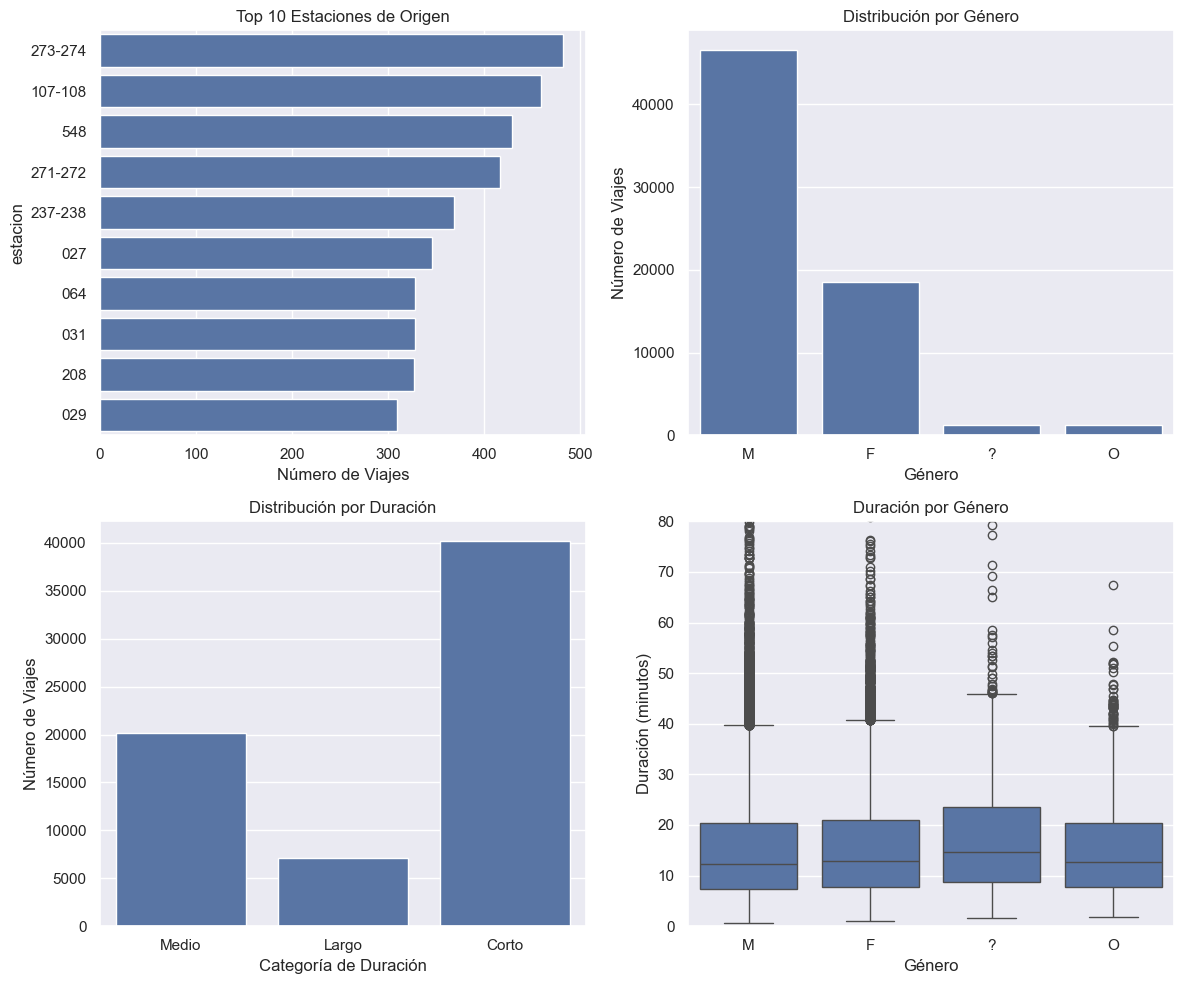


METRICAS ADICIONALES:
Viajes circulares: 1,770 (2.62%)

Duración promedio por género:
   ?: 17.8 minutos
   F: 15.7 minutos
   M: 15.2 minutos
   O: 15.4 minutos


In [4]:
# Visualizaciones básicas con Seaborn
if not bici_df.empty:
    # Crear visualizaciones
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. Top 10 estaciones de origen
    top_origen_df = estaciones_origen.head(10).reset_index()
    top_origen_df.columns = ['estacion', 'viajes']
    sns.barplot(data=top_origen_df, x='viajes', y='estacion', ax=axes[0,0])
    axes[0,0].set_title('Top 10 Estaciones de Origen')
    axes[0,0].set_xlabel('Número de Viajes')
    
    # 2. Distribución por género
    sns.countplot(data=bici_clean, x='Genero_Usuario', ax=axes[0,1])
    axes[0,1].set_title('Distribución por Género')
    axes[0,1].set_xlabel('Género')
    axes[0,1].set_ylabel('Número de Viajes')
    
    # 3. Distribución de categorías de duración
    sns.countplot(data=bici_clean, x='categoria_duracion', ax=axes[1,0])
    axes[1,0].set_title('Distribución por Duración')
    axes[1,0].set_xlabel('Categoría de Duración')
    axes[1,0].set_ylabel('Número de Viajes')
    
    # 4. Duración por género
    sns.boxplot(data=bici_clean, x='Genero_Usuario', y='duracion_mins', ax=axes[1,1])
    axes[1,1].set_title('Duración por Género')
    axes[1,1].set_xlabel('Género')
    axes[1,1].set_ylabel('Duración (minutos)')
    axes[1,1].set_ylim(0, 80)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas adicionales
    print(f"\nMETRICAS ADICIONALES:")
    
    # Viajes circulares (mismo origen y destino)
    viajes_circulares = len(bici_clean[bici_clean['Ciclo_Estacion_Retiro'] == bici_clean['Ciclo_EstacionArribo']])
    pct_circulares = viajes_circulares / len(bici_clean) * 100
    print(f"Viajes circulares: {viajes_circulares:,} ({pct_circulares:.2f}%)")
    
    # Duración promedio por género
    duracion_genero = bici_clean.groupby('Genero_Usuario')['duracion_mins'].mean()
    print(f"\nDuración promedio por género:")
    for genero, duracion in duracion_genero.items():
        print(f"   {genero}: {duracion:.1f} minutos")
        
else:
    print("No se pueden generar visualizaciones")


MODELO DE REGRESION LINEAL
Preparando datos para modelo...

RESULTADOS DEL MODELO:
   RMSE: 10.73 minutos
   R²: 0.0001
   Coeficiente (Edad): -0.0085
   Intercepto: 15.69


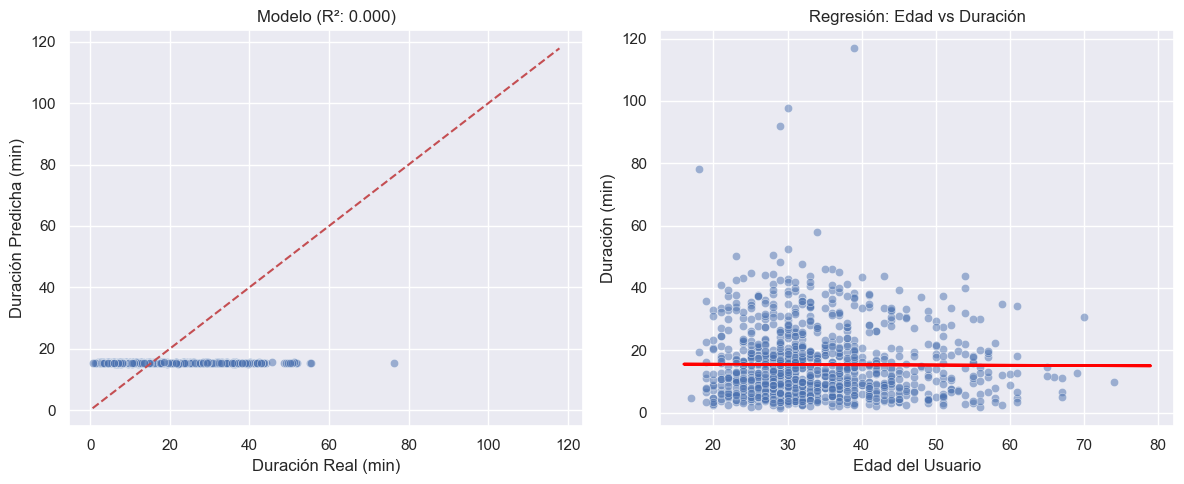

In [5]:
# Modelo simple de regresión lineal
if not bici_df.empty and len(bici_clean) > 1000:
    print("MODELO DE REGRESION LINEAL")
    print("Preparando datos para modelo...")
    
    # Preparar variables simples para el modelo
    modelo_df = bici_clean[['Edad_Usuario', 'duracion_mins']].copy()
    modelo_df = modelo_df.dropna()
    
    # Variables independientes y dependiente
    X = modelo_df[['Edad_Usuario']]
    y = modelo_df['duracion_mins']
    
    # Crear y entrenar modelo
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Hacer predicciones
    y_pred = modelo.predict(X)
    
    # Métricas
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = modelo.score(X, y)
    
    print(f"\nRESULTADOS DEL MODELO:")
    print(f"   RMSE: {rmse:.2f} minutos")
    print(f"   R²: {r2:.4f}")
    print(f"   Coeficiente (Edad): {modelo.coef_[0]:.4f}")
    print(f"   Intercepto: {modelo.intercept_:.2f}")
    
    # Visualización del modelo
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gráfico 1: Predicciones vs Reales
    sample_size = min(1000, len(y))
    sample_idx = np.random.choice(len(y), sample_size, replace=False)
    sns.scatterplot(x=y.iloc[sample_idx], y=y_pred[sample_idx], 
                    alpha=0.5, ax=axes[0])
    axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    axes[0].set_xlabel('Duración Real (min)')
    axes[0].set_ylabel('Duración Predicha (min)')
    axes[0].set_title(f'Modelo (R²: {r2:.3f})')
    
    # Gráfico 2: Edad vs Duración
    sns.scatterplot(data=modelo_df.sample(1000), x='Edad_Usuario', y='duracion_mins', 
                    alpha=0.5, ax=axes[1])
    axes[1].plot(modelo_df['Edad_Usuario'], y_pred, color='red', linewidth=2)
    axes[1].set_xlabel('Edad del Usuario')
    axes[1].set_ylabel('Duración (min)')
    axes[1].set_title('Regresión: Edad vs Duración')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No hay suficientes datos para el modelo")
